# UK House Price Predictor
## Phase 2: Feature Engineering

**Goal:** Enrich the dataset with external features (interest rates, inflation) and transform categorical variables into numeric ones ready for ML modelling.

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('dataset_clean.csv', parse_dates=['date'])

print(f'Dataset loaded: {len(df):,} transactions')
print(f'Property types present: {sorted(df["property_type"].unique())}')

Dataset loaded: 739,435 transactions
Property types present: ['D', 'F', 'S', 'T']


## 2. Time Features

In [2]:
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['quarter']     = df['date'].dt.quarter
df['day_of_week'] = df['date'].dt.dayofweek

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['season'] = df['month'].apply(get_season)

print('Time features created:')
print(df[['date', 'year', 'month', 'quarter', 'season']].head())

Time features created:
        date  year  month  quarter  season
0 2025-07-31  2025      7        3  Summer
1 2025-01-20  2025      1        1  Winter
2 2025-03-20  2025      3        1  Spring
3 2025-03-27  2025      3        1  Spring
4 2025-03-28  2025      3        1  Spring


## 3. Macroeconomic Data (2025)

We add Bank of England base rates and CPI inflation — both publicly available.
This enriches the model with economic context and differentiates it from a basic student project.

In [3]:
# Bank of England base rate by month — source: bankofengland.co.uk
boe_rates = {
    1:4.75, 2:4.50, 3:4.50, 4:4.25,
    5:4.25, 6:4.25, 7:4.25, 8:4.25,
    9:4.00, 10:4.00, 11:4.00, 12:4.00
}

# UK CPI inflation by month — source: ons.gov.uk
inflation = {
    1:3.0, 2:2.8, 3:2.6, 4:3.5,
    5:3.4, 6:3.3, 7:3.2, 8:3.1,
    9:3.0, 10:3.0, 11:2.9, 12:2.8
}

df['boe_rate']  = df['month'].map(boe_rates)
df['cpi']       = df['month'].map(inflation)

print('Macroeconomic data added:')
print(df[['month', 'boe_rate', 'cpi']].drop_duplicates().sort_values('month'))

Macroeconomic data added:
     month  boe_rate  cpi
1        1      4.75  3.0
11       2      4.50  2.8
2        3      4.50  2.6
99       4      4.25  3.5
16       5      4.25  3.4
79       6      4.25  3.3
0        7      4.25  3.2
14       8      4.25  3.1
678      9      4.00  3.0
637     10      4.00  3.0
638     11      4.00  2.9
641     12      4.00  2.8


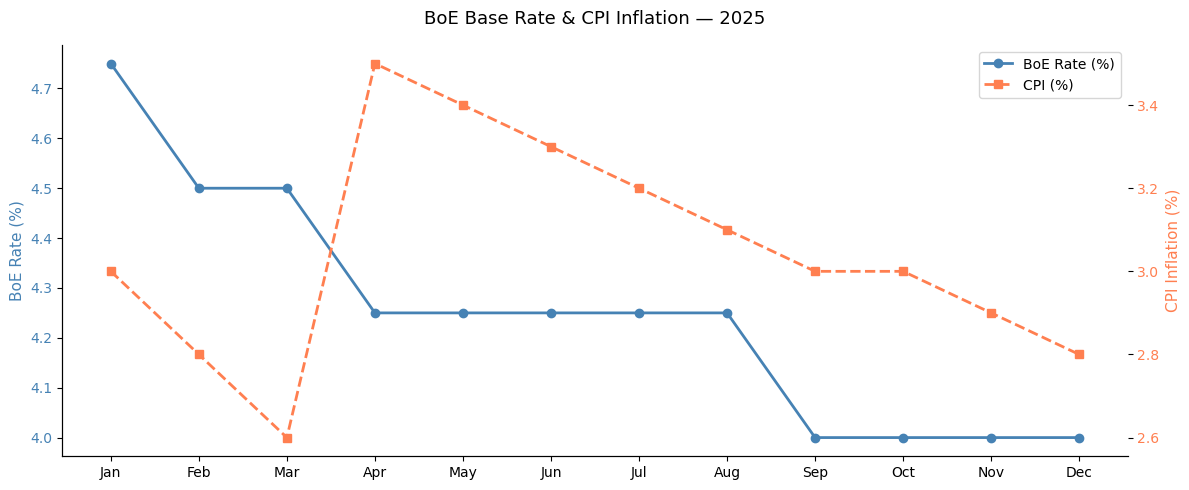

In [4]:
# Chart: BoE rate and CPI through 2025
months = sorted(boe_rates.keys())
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax1 = plt.subplots()
ax1.plot(months, [boe_rates[m] for m in months],
         marker='o', color='steelblue', linewidth=2, label='BoE Rate (%)')
ax1.set_ylabel('BoE Rate (%)', color='steelblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(months, [inflation[m] for m in months],
         marker='s', color='coral', linewidth=2, linestyle='--', label='CPI (%)')
ax2.set_ylabel('CPI Inflation (%)', color='coral', fontsize=11)
ax2.tick_params(axis='y', labelcolor='coral')

ax1.set_xticks(months)
ax1.set_xticklabels(month_labels)
ax1.set_title('BoE Base Rate & CPI Inflation — 2025', fontsize=13, pad=15)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.savefig('chart5_macro_data.png', dpi=150)
plt.show()

## 4. Encoding Categorical Variables

ML models only accept numbers. We convert categorical columns using standard encoding techniques.

In [5]:
# One-Hot Encoding for property type
property_dummies = pd.get_dummies(df['property_type'], prefix='type', drop_first=True)
df = pd.concat([df, property_dummies], axis=1)

print('Property type columns created:', list(property_dummies.columns))
print(property_dummies.head())

Property type columns created: ['type_F', 'type_S', 'type_T']
   type_F  type_S  type_T
0    True   False   False
1    True   False   False
2   False   False    True
3   False    True   False
4    True   False   False


In [6]:
# Binary encoding
df['is_new_build'] = (df['new_build'] == 'Y').astype(int)
df['is_freehold']  = (df['tenure'] == 'F').astype(int)

# Season as ordinal number
season_map = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3}
df['season_num'] = df['season'].map(season_map)

print('Encoding complete:')
print(df[['new_build','is_new_build','tenure','is_freehold','season','season_num']].head())

Encoding complete:
  new_build  is_new_build tenure  is_freehold  season  season_num
0         N             0      L            0  Summer           2
1         N             0      L            0  Winter           0
2         N             0      L            0  Spring           1
3         N             0      F            1  Spring           1
4         N             0      L            0  Spring           1


## 5. Geographic Feature: Median Price by County and Town

Location is one of the strongest predictors of house price.
We use target encoding to capture the average value of each area.

In [7]:
df['county_median'] = df['county'].map(df.groupby('county')['price'].median())
df['town_median']   = df['town'].map(df.groupby('town')['price'].median())

print('Geographic features created:')
print(df[['county','county_median','town','town_median']].head(10))

Geographic features created:
           county  county_median          town  town_median
0  GREATER LONDON       527500.0        LONDON     574000.0
1  GREATER LONDON       527500.0        LONDON     574000.0
2  GREATER LONDON       527500.0        LONDON     574000.0
3  GREATER LONDON       527500.0        BARNET     621500.0
4  GREATER LONDON       527500.0        BARNET     621500.0
5  GREATER LONDON       527500.0  WEST DRAYTON     396000.0
6  GREATER LONDON       527500.0        LONDON     574000.0
7  GREATER LONDON       527500.0        LONDON     574000.0
8  GREATER LONDON       527500.0       ENFIELD     470000.0
9  GREATER LONDON       527500.0        LONDON     574000.0


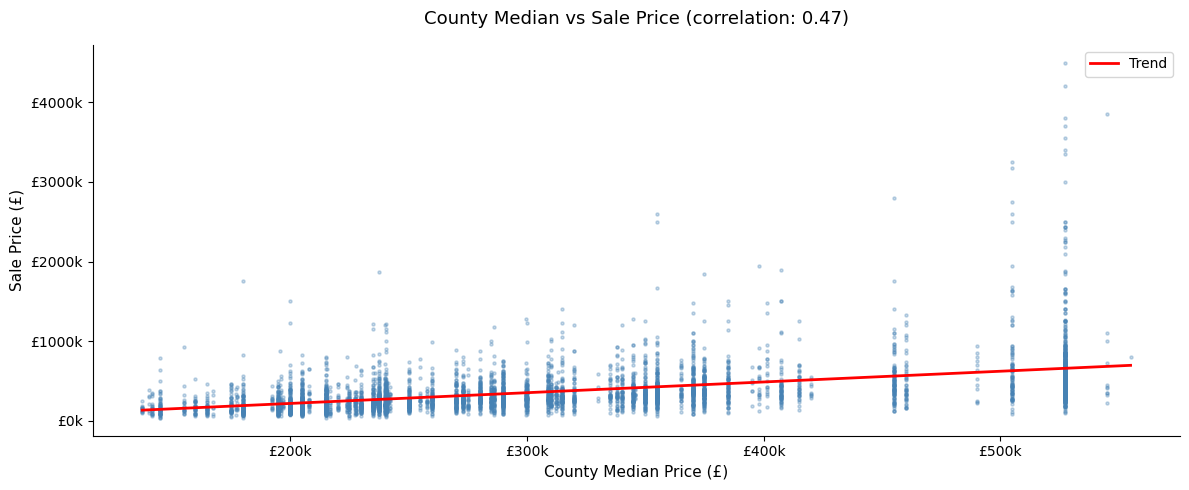

In [8]:
# Chart: county median vs sale price
sample = df.sample(min(5000, len(df)), random_state=42)

fig, ax = plt.subplots()
ax.scatter(sample['county_median'], sample['price'], alpha=0.3, s=5, color='steelblue')

z = np.polyfit(sample['county_median'], sample['price'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['county_median'].min(), sample['county_median'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Trend')

corr = sample['county_median'].corr(sample['price'])
ax.set_title(f'County Median vs Sale Price (correlation: {corr:.2f})', fontsize=13, pad=15)
ax.set_xlabel('County Median Price (£)', fontsize=11)
ax.set_ylabel('Sale Price (£)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.savefig('chart6_geographic_correlation.png', dpi=150)
plt.show()

## 6. Final Feature Selection

In [9]:
# Auto-detect one-hot encoded type columns
type_cols = [c for c in df.columns if c.startswith('type_')]
print(f'Type columns detected: {type_cols}')

features = [
    'month', 'quarter', 'season_num',
    'boe_rate', 'cpi',
    'is_new_build', 'is_freehold',
    'county_median', 'town_median',
] + type_cols

target = 'price'

df_ml = df[features + [target]].dropna()

print(f'\nML dataset ready: {len(df_ml):,} rows, {len(features)} features')
print('\nFeature list:')
for f in features:
    print(f'  - {f}')
print(f'  → TARGET: {target}')

Type columns detected: ['type_F', 'type_S', 'type_T']

ML dataset ready: 739,435 rows, 12 features

Feature list:
  - month
  - quarter
  - season_num
  - boe_rate
  - cpi
  - is_new_build
  - is_freehold
  - county_median
  - town_median
  - type_F
  - type_S
  - type_T
  → TARGET: price


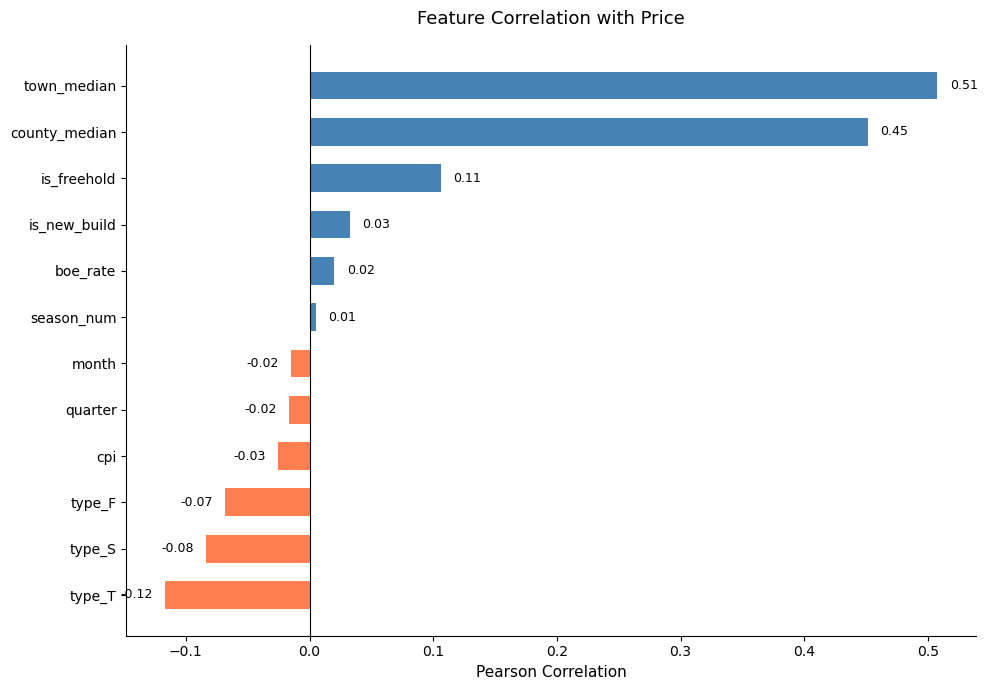

In [10]:
# Correlation chart
correlations = df_ml.corr()['price'].drop('price').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colours = ['coral' if x < 0 else 'steelblue' for x in correlations.values]
bars = ax.barh(correlations.index, correlations.values, color=colours, height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Price', fontsize=13, pad=15)
ax.set_xlabel('Pearson Correlation', fontsize=11)
for bar, val in zip(bars, correlations.values):
    offset = 0.01 if val >= 0 else -0.01
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig('chart7_correlations.png', dpi=150)
plt.show()

In [11]:
df_ml.to_csv('dataset_ml.csv', index=False)
print(f'Saved dataset_ml.csv: {len(df_ml):,} rows, {len(features)} features')
print('Ready for Phase 3!')

Saved dataset_ml.csv: 739,435 rows, 12 features
Ready for Phase 3!


## Phase 2 Summary

- ✅ Time features extracted (month, quarter, season)
- ✅ Real macroeconomic data added (BoE rate, CPI)
- ✅ Categorical variables encoded (one-hot + binary)
- ✅ Geographic features created (county and town medians)
- ✅ Feature correlations verified

**Next — Phase 3:** Train and compare Linear Regression, Random Forest, and XGBoost.